# Topomap spectral entropy

Visualizzazione della spectral entropy sui 27 canali. Le finestre vengono aggregate entro soggetto prima del confronto HC/MS, evitando pseudoreplicazione.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from ipywidgets import Dropdown, IntSlider, interact

from eeg_ms.config import CANONICAL_DATA, CHANNELS_FILE, FIGURES
from eeg_ms.visualization.topomaps import (
    load_eeg_info,
    plot_condition_contrasts,
    plot_group_comparison,
    plot_topomap,
    subject_channel_map,
)

TOPOMAP_FIGURES = FIGURES / "topomaps"
TOPOMAP_FIGURES.mkdir(parents=True, exist_ok=True)

canonical = pd.read_parquet(CANONICAL_DATA)
info = load_eeg_info(CHANNELS_FILE)

print(f"Righe canoniche: {len(canonical):,}")
print(f"Soggetti: {canonical['subject_id'].nunique()}")
print(f"Canali nel montage: {len(info.ch_names)}")


Righe canoniche: 532,224
Soggetti: 32
Canali nel montage: 27


## Controllo dei valori disponibili

In [2]:
entropy = canonical.loc[
    canonical["measure"].eq("spectral_entropy")
    & canonical["spatial_level"].eq("channel")
]

display(
    entropy.groupby(["group", "condition"])["value"]
    .agg(["count", "mean", "std", "min", "max"])
)


count      mean       std       min       max
group condition                                               
hc    CE          3888  0.659117  0.126299  0.392467  0.977161
      OE          3888  0.763291  0.124100  0.365546  0.980998
ms    CE         11664  0.696327  0.118401  0.248495  0.977399
      OE         11664  0.703310  0.165126  0.277564  0.982041

## Entropy HC/MS in CE e OE

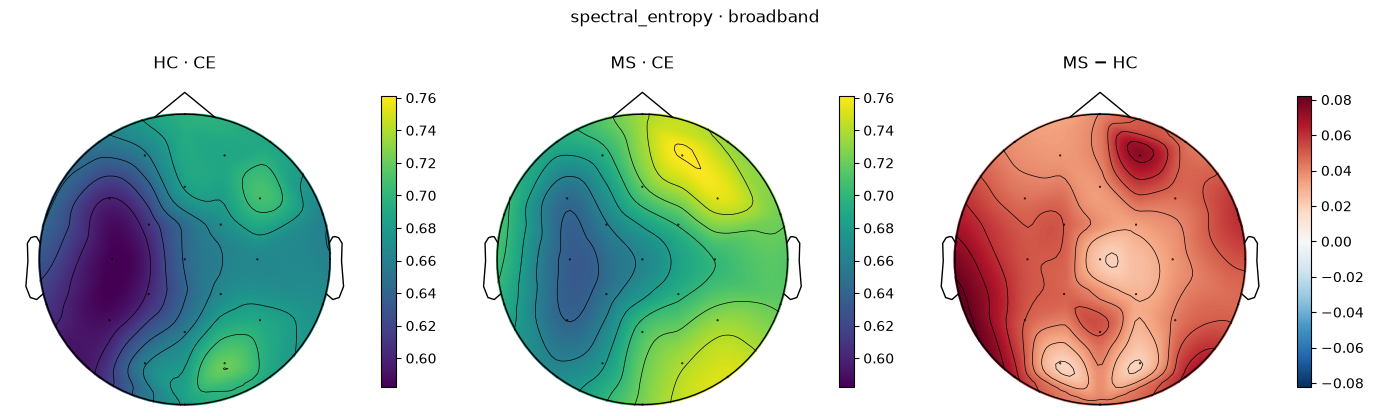

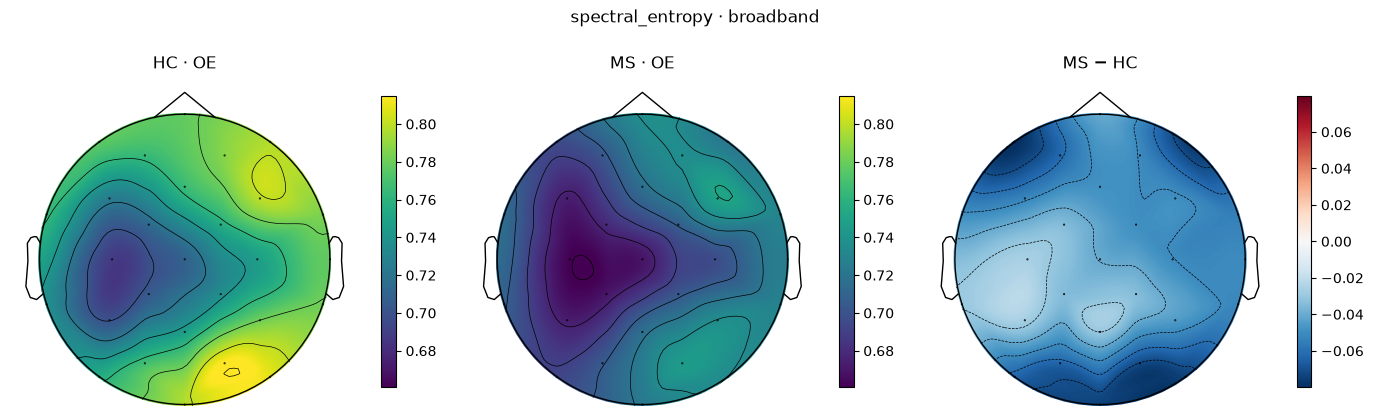

In [3]:
for condition in ["CE", "OE"]:
    figure = plot_group_comparison(
        canonical,
        info,
        condition=condition,
        measure="spectral_entropy",
        band="broadband",
    )
    figure.savefig(
        TOPOMAP_FIGURES / f"spectral_entropy_{condition}_hc_ms.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()


## Differenza appaiata CE−OE

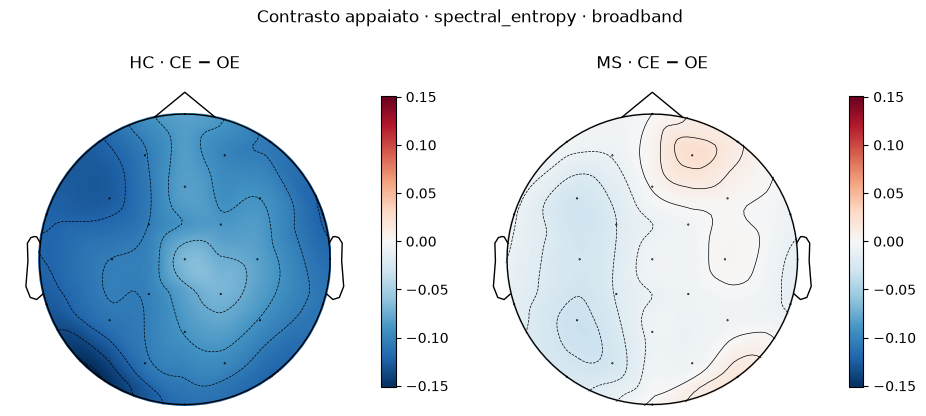

In [4]:
figure = plot_condition_contrasts(
    canonical,
    info,
    measure="spectral_entropy",
    band="broadband",
)
figure.savefig(
    TOPOMAP_FIGURES / "spectral_entropy_paired_CE_minus_OE.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


## Esplorazione interattiva per soggetto e finestra

`window=0` indica la mediana sulle finestre.

In [5]:
subject_options = sorted(canonical["subject_id"].unique())

@interact(
    subject_id=Dropdown(options=subject_options, description="Soggetto"),
    condition=Dropdown(options=["CE", "OE"], description="Condizione"),
    window=IntSlider(min=0, max=18, value=0, description="Finestra"),
)
def explore_entropy(subject_id, condition, window):
    values = subject_channel_map(
        canonical,
        info,
        subject_id=subject_id,
        condition=condition,
        measure="spectral_entropy",
        band="broadband",
        window=None if window == 0 else window,
    )
    title_window = "mediana finestre" if window == 0 else f"finestra {window}"
    figure, _ = plot_topomap(
        values,
        info,
        title=f"{subject_id} · {condition} · entropy · {title_window}",
        cmap="magma",
        vlim=(0.0, 1.0),
    )
    plt.show()


interactive(children=(Dropdown(description='Soggetto', options=('hc_01', 'hc_02', 'hc_03', 'hc_04', 'hc_05', '…

## Interpretazione

Una spectral entropy maggiore indica una distribuzione spettrale più uniforme; valori inferiori indicano maggiore concentrazione della potenza in specifiche frequenze. La scala 0–1 è appropriata solo perché le feature presenti nel dataset risultano normalizzate in tale intervallo.